VIDEO LINK:-https://drive.google.com/file/d/1sh6myf6qjehjsulwETzSG780LEAMGaY7/view?usp=sharing

# Part A — Airbnb Price Prediction & Insights

Dataset: `Airbnb_data.xlsx` (sheet: airbnb_data)


In [21]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from math import radians, sin, cos, asin, sqrt
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
print("Libraries loaded")


Libraries loaded


In [22]:
# Cell 2 — Load data
# Put Airbnb_data.xlsx in the same folder or update the path
df = pd.read_excel("Airbnb_data.xlsx", sheet_name=0)
print("rows, cols:", df.shape)
df.columns.tolist()


rows, cols: (74111, 29)


['id',
 'log_price',
 'property_type',
 'room_type',
 'amenities',
 'accommodates',
 'bathrooms',
 'bed_type',
 'cancellation_policy',
 'cleaning_fee',
 'city',
 'description',
 'first_review',
 'host_has_profile_pic',
 'host_identity_verified',
 'host_response_rate',
 'host_since',
 'instant_bookable',
 'last_review',
 'latitude',
 'longitude',
 'name',
 'neighbourhood',
 'number_of_reviews',
 'review_scores_rating',
 'thumbnail_url',
 'zipcode',
 'bedrooms',
 'beds']

In [23]:
# Cell 3 — Quick look & missing values
display(df.head(5))
print("\nMissing values (top 20):")
print(df.isna().sum().sort_values(ascending=False).head(20))
print("\nData types:")
print(df.dtypes)


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0



Missing values (top 20):
host_response_rate        18299
review_scores_rating      16722
first_review              15864
last_review               15827
thumbnail_url              8216
neighbourhood              6872
zipcode                     968
bathrooms                   200
host_identity_verified      188
host_since                  188
host_has_profile_pic        188
beds                        131
bedrooms                     91
name                         10
description                   6
property_type                 0
room_type                     0
amenities                     0
number_of_reviews             0
accommodates                  0
dtype: int64

Data types:
id                          int64
log_price                 float64
property_type              object
room_type                  object
amenities                  object
accommodates                int64
bathrooms                 float64
bed_type                   object
cancellation_policy        object
cl

In [24]:
# Cell 4 — Create original price (from log_price) and basic cleaning
if 'log_price' not in df.columns:
    raise ValueError("log_price column not found")

# assume log_price is natural log; if log1p used change np.exp -> np.expm1 accordingly
df['price'] = np.exp(df['log_price'])

# Drop obvious non-feature columns
drop_cols = ['thumbnail_url', 'description', 'name', 'id']  # keep unless you want text analysis
for c in drop_cols:
    if c in df.columns:
        df.drop(columns=c, inplace=True)

# Convert date columns (dayfirst=True to match your dataset format)
for c in ['host_since', 'first_review', 'last_review']:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=True)

print("Cleaned basic columns. New shape:", df.shape)


Cleaned basic columns. New shape: (74111, 26)


In [25]:
# Cell 5 — Feature engineering (amenities, host age, distance, binary flags)
import re

# Amenities: create amen_text (lower, comma-separated), num_amenities and top amen flags
def amen_text_from_raw(s):
    if pd.isna(s): return ""
    s = re.sub(r'[\{\}\"]', '', str(s))
    s = re.sub(r'\||;', ',', s)
    return s.lower()

if 'amenities' in df.columns:
    df['amen_text'] = df['amenities'].apply(amen_text_from_raw)
    df['num_amenities'] = df['amen_text'].apply(lambda x: 0 if x=="" else len([i for i in x.split(',') if i.strip()]))
    top_amenities = ['wifi','kitchen','air conditioning','heating','free parking','washer','dryer','tv']
    for a in top_amenities:
        df['amen_' + a.replace(" ", "_")] = df['amen_text'].str.contains(a).fillna(False).astype(int)
else:
    df['num_amenities'] = 0

# Host age (days)
today = pd.Timestamp.today()
if 'host_since' in df.columns:
    df['host_since_days'] = (today - df['host_since']).dt.days.fillna(-1).astype(int)
else:
    df['host_since_days'] = -1

# Reviews: fill missing with 0
for c in ['number_of_reviews','review_scores_rating']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

# Bedrooms/beds/bathrooms/accommodates numeric fill
for c in ['bedrooms','beds','bathrooms','accommodates']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(df[c].median())

# Distance to city center (median lat/lon as center)
if {'latitude','longitude'}.issubset(df.columns):
    lat = df['latitude'].astype(float).to_numpy()
    lon = df['longitude'].astype(float).to_numpy()
    center_lat = np.nanmedian(lat)
    center_lon = np.nanmedian(lon)
    def haversine_vec(lon1, lat1, lon2, lat2):
        lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))
        dlon = lon2 - lon1; dlat = lat2 - lat1
        a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
        c = 2 * np.arcsin(np.sqrt(a))
        return 6371 * c
    df['dist_to_center_km'] = haversine_vec(lon, lat, center_lon, center_lat)
else:
    df['dist_to_center_km'] = -1

# Frequency encode high-cardinality location columns
for col in ['neighbourhood','zipcode','city']:
    if col in df.columns:
        freq = df[col].fillna('missing').astype(str).value_counts(normalize=True)
        df[col + '_freq'] = df[col].fillna('missing').astype(str).map(freq).fillna(0.0)

print("Feature engineering completed.")


Feature engineering completed.


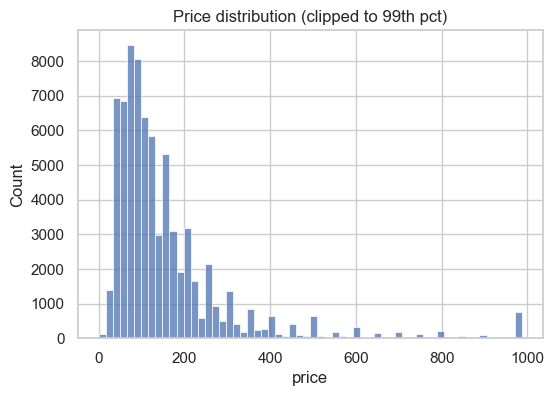

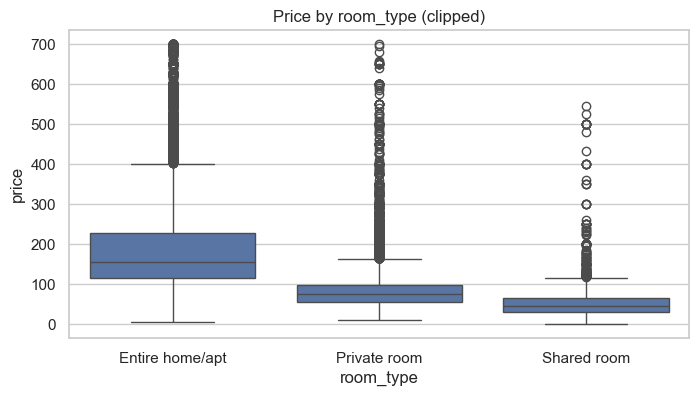

In [26]:
# Cell 6 — Quick EDA plots (price distribution, price vs room_type, price map snippet)
plt.figure(figsize=(6,4))
sns.histplot(df['price'].clip(upper=df['price'].quantile(0.99)), bins=60)
plt.title("Price distribution (clipped to 99th pct)")
plt.show()

if 'room_type' in df.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='room_type', y='price', data=df[df['price']<df['price'].quantile(0.98)])
    plt.title("Price by room_type (clipped)")
    plt.show()


In [27]:
# Cell 7 — Prepare features & target; drop unused columns
# Choose features to include (you can edit)
feat_candidates = [
    'property_type','room_type','accommodates','bathrooms','bedrooms','beds',
    'number_of_reviews','review_scores_rating','cleaning_fee','instant_bookable',
    'host_since_days','host_has_profile_pic','host_identity_verified',
    'num_amenities','dist_to_center_km','neighbourhood_freq','zipcode_freq','city_freq'
]
# keep only columns that exist
features = [c for c in feat_candidates if c in df.columns]
print("Using features:", features)

# Prepare X,y
X = df[features].copy()
y_log = df['log_price'].astype(float).values         # model target (log price)
y_price = df['price'].values                         # original price (for final metrics)

# Convert boolean-like columns to consistent numeric (0/1)
for c in X.columns:
    if X[c].dtype == 'bool':
        X[c] = X[c].astype(int)
# Also convert 'yes'/'no' string columns if present
for c in ['instant_bookable','cleaning_fee','host_has_profile_pic','host_identity_verified']:
    if c in X.columns:
        X[c] = X[c].astype(str).str.lower().isin(['true','yes','y','1','t']).astype(int)

# Convert categorical placeholders to strings
cat_cols = [c for c in features if X[c].dtype == 'object']
for c in cat_cols:
    X[c] = X[c].fillna('missing').astype(str)

print("Prepared X,y. X shape:", X.shape)


Using features: ['property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'cleaning_fee', 'instant_bookable', 'host_since_days', 'host_has_profile_pic', 'host_identity_verified', 'num_amenities', 'dist_to_center_km', 'neighbourhood_freq', 'zipcode_freq', 'city_freq']
Prepared X,y. X shape: (74111, 18)


In [28]:
# Cell 8 — Train / Validation / Test split (stratified if needed)
# We'll create train+val, then test split. Use random_state for reproducibility.
X_temp, X_test, y_log_temp, y_log_test, y_price_temp, y_price_test = train_test_split(
    X, y_log, y_price, test_size=0.10, random_state=42)

X_train, X_val, y_log_train, y_log_val, y_price_train, y_price_val = train_test_split(
    X_temp, y_log_temp, y_price_temp, test_size=0.1111, random_state=42)  # ~10% val of full

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (59288, 18) Val: (7411, 18) Test: (7412, 18)


In [29]:
# Cell 9 — Preprocessing pipelines (numeric + categorical); ensure dense OHE
numeric_features = [c for c in features if X[c].dtype in ['int64','float64']]
categorical_features = [c for c in features if X[c].dtype == 'object']

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

num_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

cat_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, numeric_features),
    ('cat', cat_transformer, categorical_features)
], remainder='drop')


Numeric: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'cleaning_fee', 'instant_bookable', 'host_since_days', 'host_has_profile_pic', 'host_identity_verified', 'num_amenities', 'dist_to_center_km', 'neighbourhood_freq', 'zipcode_freq', 'city_freq']
Categorical: ['property_type', 'room_type']


In [30]:
# Cell 10 — Model pipeline (train on log target)
model = Pipeline([
    ('pre', preprocessor),
    ('clf', HistGradientBoostingRegressor(random_state=42, max_iter=150))
])

# Convert any mixed-type categorical columns in the train/val/test split to str to avoid encoder issues
for c in categorical_features:
    X_train[c] = X_train[c].astype(str)
    X_val[c] = X_val[c].astype(str)
    X_test[c] = X_test[c].astype(str)

# Fit
print("Training model...")
model.fit(X_train, y_log_train)
print("Model trained")


Training model...
Model trained


In [31]:
# Cell 11 — Evaluate on validation and test 

def evaluate_on_set(model, X_set, y_log_true, y_price_true, label="set"):
    y_log_pred = model.predict(X_set)
    y_price_pred = np.exp(y_log_pred)  # inverse of natural log

    # Compatibility fix: sklearn <0.22 doesn't support squared=False
    rmse = np.sqrt(mean_squared_error(y_price_true, y_price_pred))
    mae = mean_absolute_error(y_price_true, y_price_pred)
    r2 = r2_score(y_price_true, y_price_pred)

    print(f"Metrics on {label}: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.3f}")
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'y_price_pred': y_price_pred, 'y_log_pred': y_log_pred}

# Evaluate
val_metrics = evaluate_on_set(model, X_val, y_log_val, y_price_val, label="validation")
test_metrics = evaluate_on_set(model, X_test, y_log_test, y_price_test, label="test")



Metrics on validation: RMSE=114.16, MAE=51.12, R2=0.565
Metrics on test: RMSE=112.11, MAE=50.52, R2=0.557


,true_price,pred_price,true_log,pred_log
0,45.0,58.261664,3.806662,4.064944
1,140.0,135.471904,4.941642,4.908764
2,140.0,123.338685,4.941642,4.814934
3,130.0,232.252740,4.867534,5.447826
4,39.0,48.962996,3.663562,3.891065
5,126.0,155.403437,4.836282,5.046025
6,185.0,191.841327,5.220356,5.256669
7,295.0,157.686090,5.686975,5.060606
8,35.0,56.430135,3.555348,4.033003
9,69.0,99.866335,4.234107,4.603833


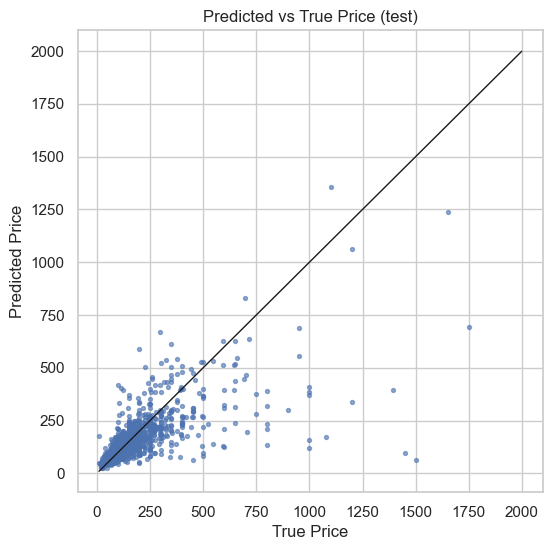

In [32]:
# Cell 12 — Predictions sample & residual plot
# show first 15 predictions vs true prices on test set
res_df = pd.DataFrame({
    'true_price': y_price_test,
    'pred_price': test_metrics['y_price_pred'],
    'true_log': y_log_test,
    'pred_log': test_metrics['y_log_pred']
})
display(res_df.head(15))

# Scatter predicted vs true
plt.figure(figsize=(6,6))
idx = np.random.RandomState(1).choice(range(len(y_price_test)), size=min(1500, len(y_price_test)), replace=False)
plt.scatter(y_price_test[idx], test_metrics['y_price_pred'][idx], s=8, alpha=0.6)
mn, mx = y_price_test.min(), y_price_test.max()
plt.plot([mn,mx],[mn,mx], color='k', linewidth=1)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs True Price (test)")
plt.show()


In [33]:
# Cell 13 — Feature importance (model-based) and top features
# get feature names after preprocessing
ohe = model.named_steps['pre'].named_transformers_['cat'].named_steps['ohe']
ohe_cols = list(ohe.get_feature_names_out(categorical_features)) if len(categorical_features)>0 else []
feature_names = numeric_features + ohe_cols
try:
    importances = model.named_steps['clf'].feature_importances_
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(30)
    display(imp_df)
    # bar plot top 15
    plt.figure(figsize=(8,6))
    top = imp_df.head(15)[::-1]
    plt.barh(top['feature'], top['importance'])
    plt.title("Top 15 feature importances (model)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Model does not expose feature_importances_: ", e)


Model does not expose feature_importances_:  'HistGradientBoostingRegressor' object has no attribute 'feature_importances_'


In [34]:
# Cell 14 — SHAP (optional, a few steps; large datasets slow)
# Only run if you installed shap and have time/compute.
try:
    import shap
    # Create explainer on small subset to speed up
    X_sample = X_train.sample(n=min(2000, X_train.shape[0]), random_state=1)
    pre = model.named_steps['pre']
    X_pre = pre.transform(X_sample)
    explainer = shap.Explainer(model.named_steps['clf'])
    shap_vals = explainer(X_pre)
    shap.summary_plot(shap_vals, features=X_pre, feature_names=feature_names, show=True)
except Exception as e:
    print("SHAP not run (optional). Reason:", e)


SHAP not run (optional). Reason: No module named 'shap'


In [35]:
import json
import numpy as np

# Convert all numpy objects to plain Python types before saving
def convert_to_serializable(obj):
    if isinstance(obj, (np.integer, np.int64)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.ndarray, list, tuple)):
        return [convert_to_serializable(x) for x in obj]
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    else:
        return obj

# Create summary
summary = {
    'features': list(features),
    'numeric_features': list(numeric_features),
    'categorical_features': list(categorical_features),
    'val_metrics': val_metrics,
    'test_metrics': test_metrics
}

# Convert safely
summary_serializable = convert_to_serializable(summary)

# Save to JSON
with open("airbnb_model_summary.json", "w") as f:
    json.dump(summary_serializable, f, indent=2)

print("✅ Saved pipeline and summary to disk successfully!")



✅ Saved pipeline and summary to disk successfully!
